In [ ]:
from google.colab import files

uploaded = files.upload()


Saving store.csv to store.csv
Saving test.csv to test.csv
Saving train.csv to train.csv


In [ ]:
import os

os.listdir()

['.config', 'store.csv', 'test.csv', 'train.csv', 'sample_data']

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
store = pd.read_csv("store.csv")

/tmp/ipykernel_319/1336641893.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("train.csv")


In [ ]:
print("Train:", train.shape)
print("Test:", test.shape)
print("Store:", store.shape)

Train: (1017209, 9)
Test: (41088, 8)
Store: (1115, 10)


In [ ]:
print("TRAIN COLUMNS:")
print(train.columns.tolist())

print("\nTEST COLUMNS:")
print(test.columns.tolist())

print("\nSTORE COLUMNS:")
print(store.columns.tolist())

TRAIN COLUMNS:
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']

TEST COLUMNS:
['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']

STORE COLUMNS:
['Store', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


In [ ]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [ ]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [ ]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [ ]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [ ]:
print("TRAIN MISSING VALUES")
print(train.isnull().sum())

print("\nSTORE MISSING VALUES")
print(store.isnull().sum())

TRAIN MISSING VALUES
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

STORE MISSING VALUES
Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


In [ ]:
print("TRAIN DUPLICATES:", train.duplicated().sum())
print("STORE DUPLICATES:", store.duplicated().sum())

TRAIN DUPLICATES: 0
STORE DUPLICATES: 0


In [ ]:
store.groupby("Promo2")[[
    "Promo2SinceWeek",
    "Promo2SinceYear",
    "PromoInterval"
]].apply(lambda x: x.isnull().sum())

,Promo2SinceWeek,Promo2SinceYear,PromoInterval
Promo2,,,
0,544,544,544
1,0,0,0


In [ ]:
store["Promo2"].value_counts()

,count
Promo2,
1,571
0,544


In [ ]:
train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])

In [ ]:
print(train["Date"].dtype)
print(test["Date"].dtype)

datetime64[ns]
datetime64[ns]


In [ ]:
daily_sales = train.groupby("Date")["Sales"].sum()

daily_sales.head()

,Sales
Date,
2013-01-01,97235
2013-01-02,6949829
2013-01-03,6347820
2013-01-04,6638954
2013-01-05,5951593


In [ ]:
daily_sales.tail()

,Sales
Date,
2015-07-27,10707292
2015-07-28,9115073
2015-07-29,8499962
2015-07-30,8798854
2015-07-31,10109742


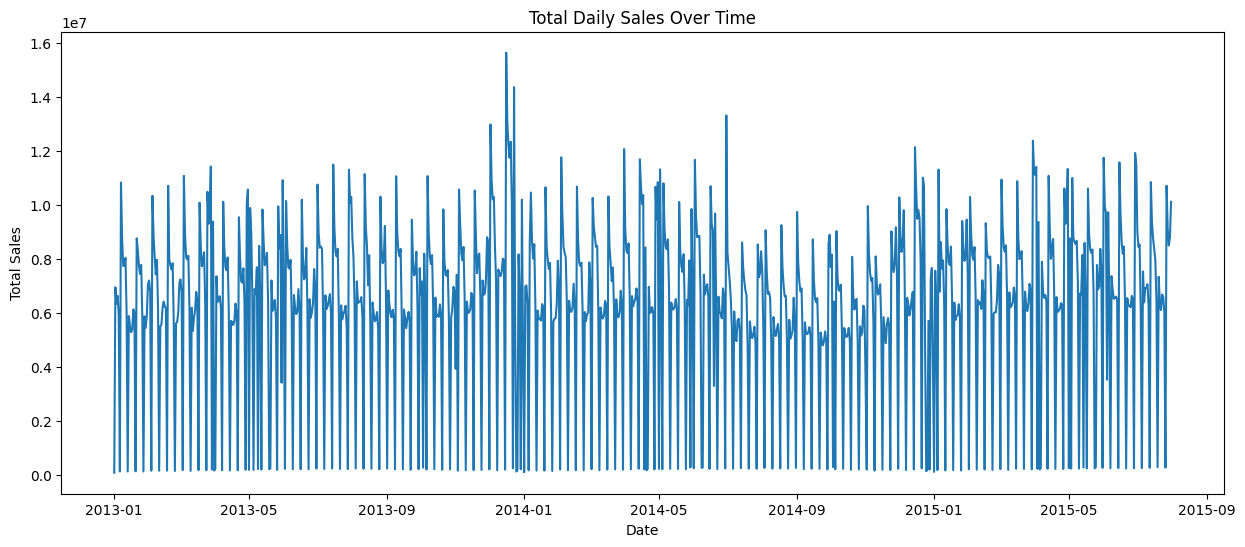

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(daily_sales)

plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

In [ ]:
print("Open = 0 olan kayıtlar:")
print((train["Open"] == 0).sum())

print("\nSales = 0 olan kayıtlar:")
print((train["Sales"] == 0).sum())

print("\nHem Open = 0 hem Sales = 0:")
print(((train["Open"] == 0) & (train["Sales"] == 0)).sum())

Open = 0 olan kayıtlar:
172817

Sales = 0 olan kayıtlar:
172871

Hem Open = 0 hem Sales = 0:
172817


In [ ]:
pd.crosstab(train["Open"], train["Sales"] == 0)

Sales,False,True
Open,,
0,0,172817
1,844338,54


In [ ]:
daily_sales_by_weekday = (
    train[train["Open"] == 1]
    .groupby("DayOfWeek")["Sales"]
    .mean()
)

daily_sales_by_weekday

,Sales
DayOfWeek,
1,8216.073074
2,7088.113656
3,6728.122978
4,6767.310159
5,7072.677012
6,5874.840238
7,8224.723908


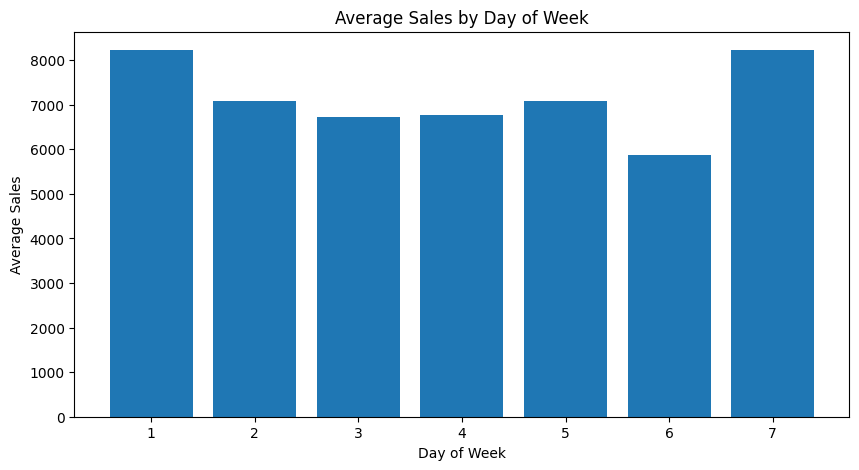

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    daily_sales_by_weekday.index,
    daily_sales_by_weekday.values
)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")

plt.xticks(range(1, 8))

plt.show()

In [ ]:
day_names = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}

daily_sales_by_weekday.index = daily_sales_by_weekday.index.map(day_names)

daily_sales_by_weekday

,Sales
DayOfWeek,
Monday,8216.073074
Tuesday,7088.113656
Wednesday,6728.122978
Thursday,6767.310159
Friday,7072.677012
Saturday,5874.840238
Sunday,8224.723908


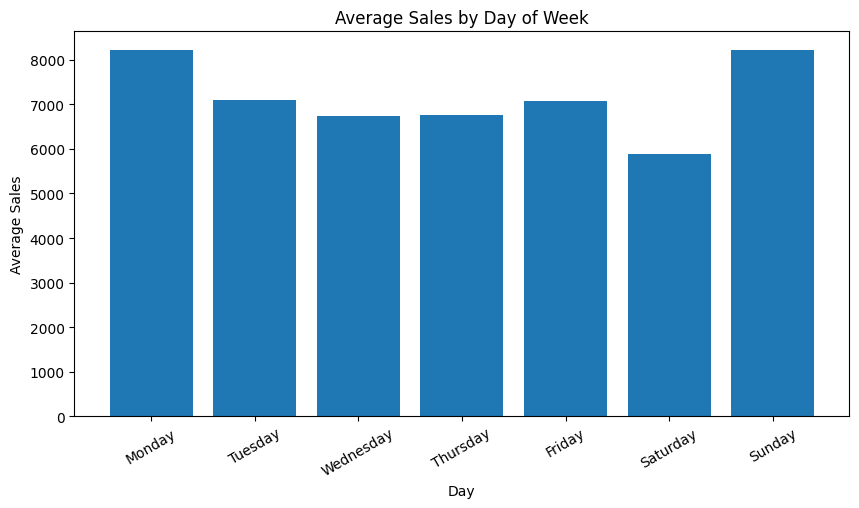

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    daily_sales_by_weekday.index,
    daily_sales_by_weekday.values
)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Sales")

plt.xticks(rotation=30)

plt.show()

In [ ]:
promo_sales = (
    train[train["Open"] == 1]
    .groupby("Promo")["Sales"]
    .mean()
)

promo_sales

,Sales
Promo,
0,5929.407603
1,8228.281239


In [ ]:
print("Promo yokken ortalama satış:", round(promo_sales[0], 2))
print("Promo varken ortalama satış:", round(promo_sales[1], 2))

Promo yokken ortalama satış: 5929.41
Promo varken ortalama satış: 8228.28


In [ ]:
promo_counts = train[train["Open"] == 1]["Promo"].value_counts()

promo_counts

,count
Promo,
0,467496
1,376896


In [ ]:
promo_percentage = (
    train[train["Open"] == 1]["Promo"]
    .value_counts(normalize=True) * 100
)

promo_percentage

,proportion
Promo,
0,55.364807
1,44.635193


In [ ]:
promo_by_day = pd.crosstab(
    train[train["Open"] == 1]["DayOfWeek"],
    train[train["Open"] == 1]["Promo"],
    normalize="index"
) * 100

promo_by_day

Promo,0,1
DayOfWeek,,
1,43.847776,56.152224
2,46.431325,53.568675
3,46.273673,53.726327
4,44.948902,55.051098
5,47.955136,52.044864
6,100.000000,0.000000
7,100.000000,0.000000


In [ ]:
promo_by_day.index = promo_by_day.index.map(day_names)

promo_by_day.columns = ["No Promo (%)", "Promo (%)"]

promo_by_day

,No Promo (%),Promo (%)
DayOfWeek,,
Monday,43.847776,56.152224
Tuesday,46.431325,53.568675
Wednesday,46.273673,53.726327
Thursday,44.948902,55.051098
Friday,47.955136,52.044864
Saturday,100.000000,0.000000
Sunday,100.000000,0.000000


In [ ]:
store_sales = (
    train[train["Open"] == 1]
    .groupby("Store")["Sales"]
    .mean()
)

print("Mağaza sayısı:", store_sales.shape[0])

print("\nEn yüksek ortalama satış yapan 10 mağaza:")
print(store_sales.sort_values(ascending=False).head(10))

print("\nEn düşük ortalama satış yapan 10 mağaza:")
print(store_sales.sort_values().head(10))

Mağaza sayısı: 1115

En yüksek ortalama satış yapan 10 mağaza:
Store
817     21757.483418
262     20718.515924
1114    20666.562500
251     19123.068036
842     18574.795820
513     18179.089286
562     17969.556263
788     17961.914541
383     17294.716667
756     16574.816431
Name: Sales, dtype: float64

En düşük ortalama satış yapan 10 mağaza:
Store
307    2703.736573
543    2790.380282
198    2900.604859
208    2936.290816
841    2972.608974
254    3005.983312
794    3083.812821
219    3133.712452
210    3193.984596
425    3237.659794
Name: Sales, dtype: float64


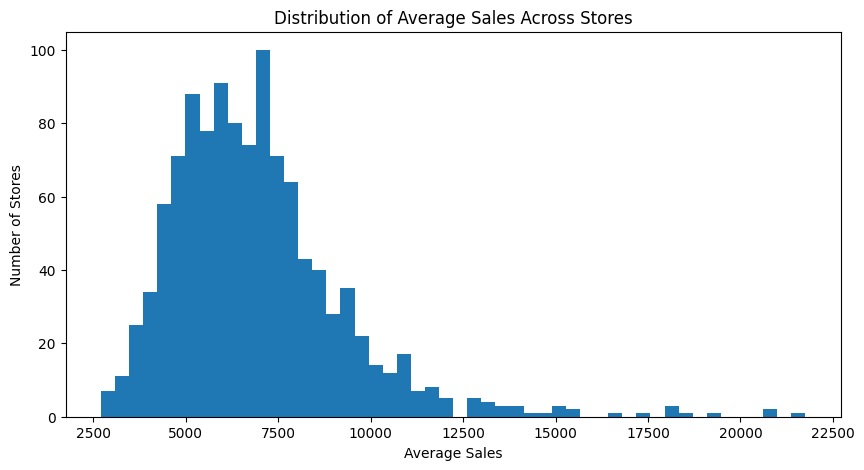

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(store_sales, bins=50)

plt.title("Distribution of Average Sales Across Stores")
plt.xlabel("Average Sales")
plt.ylabel("Number of Stores")

plt.show()

In [ ]:
print("Train'deki mağaza sayısı:", train["Store"].nunique())
print("Store.csv'deki mağaza sayısı:", store["Store"].nunique())

print(
    "Train'de olup store.csv'de olmayan mağaza:",
    len(set(train["Store"]) - set(store["Store"]))
)

Train'deki mağaza sayısı: 1115
Store.csv'deki mağaza sayısı: 1115
Train'de olup store.csv'de olmayan mağaza: 0


In [ ]:
train_merged = train.merge(
    store,
    on="Store",
    how="left"
)

In [ ]:
print("Train shape:", train.shape)
print("Merged shape:", train_merged.shape)

Train shape: (1017209, 9)
Merged shape: (1017209, 18)


In [ ]:
train_merged.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [ ]:
train_merged["Date"].min(), train_merged["Date"].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [ ]:
train_merged["Year"] = train_merged["Date"].dt.year
train_merged["Month"] = train_merged["Date"].dt.month
train_merged["Day"] = train_merged["Date"].dt.day
train_merged["WeekOfYear"] = train_merged["Date"].dt.isocalendar().week.astype(int)
train_merged["Quarter"] = train_merged["Date"].dt.quarter

In [ ]:
train_merged[
    ["Date", "Year", "Month", "Day", "WeekOfYear", "Quarter"]
].head()

,Date,Year,Month,Day,WeekOfYear,Quarter
0,2015-07-31,2015,7,31,31,3
1,2015-07-31,2015,7,31,31,3
2,2015-07-31,2015,7,31,31,3
3,2015-07-31,2015,7,31,31,3
4,2015-07-31,2015,7,31,31,3


In [ ]:
train_merged["IsWeekend"] = (
    train_merged["DayOfWeek"].isin([6, 7]).astype(int)
)

In [ ]:
train_merged[
    ["DayOfWeek", "IsWeekend"]
].drop_duplicates().sort_values("DayOfWeek")

,DayOfWeek,IsWeekend
4460,1,0
3345,2,0
2230,3,0
1115,4,0
0,5,0
6690,6,1
5575,7,1


In [ ]:
test["Year"] = test["Date"].dt.year
test["Month"] = test["Date"].dt.month
test["Day"] = test["Date"].dt.day
test["WeekOfYear"] = test["Date"].dt.isocalendar().week.astype(int)
test["Quarter"] = test["Date"].dt.quarter

test["IsWeekend"] = (
    test["DayOfWeek"].isin([6, 7]).astype(int)
)

In [ ]:
test[
    [
        "Date",
        "DayOfWeek",
        "Year",
        "Month",
        "Day",
        "WeekOfYear",
        "Quarter",
        "IsWeekend"
    ]
].head()

,Date,DayOfWeek,Year,Month,Day,WeekOfYear,Quarter,IsWeekend
0,2015-09-17,4,2015,9,17,38,3,0
1,2015-09-17,4,2015,9,17,38,3,0
2,2015-09-17,4,2015,9,17,38,3,0
3,2015-09-17,4,2015,9,17,38,3,0
4,2015-09-17,4,2015,9,17,38,3,0


In [ ]:
print("Train başlangıç:", train_merged["Date"].min())
print("Train bitiş:", train_merged["Date"].max())

print("Test başlangıç:", test["Date"].min())
print("Test bitiş:", test["Date"].max())

Train başlangıç: 2013-01-01 00:00:00
Train bitiş: 2015-07-31 00:00:00
Test başlangıç: 2015-08-01 00:00:00
Test bitiş: 2015-09-17 00:00:00


In [ ]:
validation_start = pd.Timestamp("2015-06-20")

train_data = train_merged[
    train_merged["Date"] < validation_start
].copy()

validation_data = train_merged[
    train_merged["Date"] >= validation_start
].copy()

print("Train:", train_data.shape)
print("Validation:", validation_data.shape)

print("\nTrain tarihleri:")
print(train_data["Date"].min(), "→", train_data["Date"].max())

print("\nValidation tarihleri:")
print(validation_data["Date"].min(), "→", validation_data["Date"].max())

Train: (970379, 24)
Validation: (46830, 24)

Train tarihleri:
2013-01-01 00:00:00 → 2015-06-19 00:00:00

Validation tarihleri:
2015-06-20 00:00:00 → 2015-07-31 00:00:00


In [ ]:
features = [
    "Store",
    "DayOfWeek",
    "Open",
    "Promo",
    "StateHoliday",
    "SchoolHoliday",
    "StoreType",
    "Assortment",
    "CompetitionDistance",
    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear",
    "Promo2",
    "Promo2SinceWeek",
    "Promo2SinceYear",
    "PromoInterval",
    "Year",
    "Month",
    "Day",
    "WeekOfYear",
    "Quarter",
    "IsWeekend"
]

target = "Sales"

In [ ]:
X_train = train_data[features].copy()
y_train = train_data[target].copy()

X_val = validation_data[features].copy()
y_val = validation_data[target].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (970379, 21)
y_train: (970379,)
X_val: (46830, 21)
y_val: (46830,)


In [ ]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.2 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor

In [ ]:
categorical_features = [
    "Store",
    "DayOfWeek",
    "StateHoliday",
    "StoreType",
    "Assortment",
    "PromoInterval"
]

In [ ]:
categorical_features = [
    "Store",
    "DayOfWeek",
    "StateHoliday",
    "StoreType",
    "Assortment",
    "PromoInterval"
]

for col in categorical_features:
    X_train[col] = X_train[col].fillna("Unknown").astype(str)
    X_val[col] = X_val[col].fillna("Unknown").astype(str)

In [ ]:
X_train[categorical_features].head()

,Store,DayOfWeek,StateHoliday,StoreType,Assortment,PromoInterval
46830,1,5,0,c,a,Unknown
46831,2,5,0,a,a,"Jan,Apr,Jul,Oct"
46832,3,5,0,a,a,"Jan,Apr,Jul,Oct"
46833,4,5,0,c,c,Unknown
46834,5,5,0,a,a,Unknown


In [ ]:
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

In [ ]:
model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50
)

0:	learn: 3549.3638721	test: 3448.3873345	best: 3448.3873345 (0)	total: 2.32s	remaining: 19m 19s
100:	learn: 1148.0629986	test: 1175.9878661	best: 1175.9878661 (100)	total: 2m 34s	remaining: 10m 11s
200:	learn: 1022.2060317	test: 1082.8092355	best: 1082.8092355 (200)	total: 5m 8s	remaining: 7m 38s
300:	learn: 951.6267860	test: 1027.3221725	best: 1027.3221725 (300)	total: 7m 43s	remaining: 5m 6s
400:	learn: 910.1159083	test: 1000.5632784	best: 1000.5225314 (399)	total: 10m 22s	remaining: 2m 33s
499:	learn: 878.3639410	test: 986.0696528	best: 984.8522614 (490)	total: 13m	remaining: 0us

bestTest = 984.8522614
bestIteration = 490

Shrink model to first 491 iterations.


CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=500, learning_rate=0.1, loss_function='RMSE', random_seed=42, verbose=100)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_val)

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

MAE : 658.37
RMSE: 984.85
R²  : 0.9301


In [ ]:
train_merged = train_merged.sort_values(["Store", "Date"])

train_merged["Sales_Lag_1"] = (
    train_merged.groupby("Store")["Sales"].shift(1)
)

In [ ]:
train_merged[
    ["Store", "Date", "Sales", "Sales_Lag_1"]
].head(20)

,Store,Date,Sales,Sales_Lag_1
1016095,1,2013-01-01,0,NaN
1014980,1,2013-01-02,5530,0.0
1013865,1,2013-01-03,4327,5530.0
1012750,1,2013-01-04,4486,4327.0
1011635,1,2013-01-05,4997,4486.0
1010520,1,2013-01-06,0,4997.0
1009405,1,2013-01-07,7176,0.0
1008290,1,2013-01-08,5580,7176.0
1007175,1,2013-01-09,5471,5580.0
1006060,1,2013-01-10,4892,5471.0


In [ ]:
train_merged["Sales_Lag_7"] = (
    train_merged.groupby("Store")["Sales"].shift(7)
)

In [ ]:
train_merged[
    ["Store", "Date", "Sales", "Sales_Lag_1", "Sales_Lag_7"]
].head(15)

,Store,Date,Sales,Sales_Lag_1,Sales_Lag_7
1016095,1,2013-01-01,0,NaN,NaN
1014980,1,2013-01-02,5530,0.0,NaN
1013865,1,2013-01-03,4327,5530.0,NaN
1012750,1,2013-01-04,4486,4327.0,NaN
1011635,1,2013-01-05,4997,4486.0,NaN
1010520,1,2013-01-06,0,4997.0,NaN
1009405,1,2013-01-07,7176,0.0,NaN
1008290,1,2013-01-08,5580,7176.0,0.0
1007175,1,2013-01-09,5471,5580.0,5530.0
1006060,1,2013-01-10,4892,5471.0,4327.0


In [ ]:
train_merged["Sales_Lag_14"] = (
    train_merged.groupby("Store")["Sales"].shift(14)
)

In [ ]:
train_merged[
    ["Store", "Date", "Sales", "Sales_Lag_1", "Sales_Lag_7", "Sales_Lag_14"]
].head(20)

,Store,Date,Sales,Sales_Lag_1,Sales_Lag_7,Sales_Lag_14
1016095,1,2013-01-01,0,NaN,NaN,NaN
1014980,1,2013-01-02,5530,0.0,NaN,NaN
1013865,1,2013-01-03,4327,5530.0,NaN,NaN
1012750,1,2013-01-04,4486,4327.0,NaN,NaN
1011635,1,2013-01-05,4997,4486.0,NaN,NaN
1010520,1,2013-01-06,0,4997.0,NaN,NaN
1009405,1,2013-01-07,7176,0.0,NaN,NaN
1008290,1,2013-01-08,5580,7176.0,0.0,NaN
1007175,1,2013-01-09,5471,5580.0,5530.0,NaN
1006060,1,2013-01-10,4892,5471.0,4327.0,NaN


In [ ]:
train_merged["Sales_Rolling_7"] = (
    train_merged.groupby("Store")["Sales"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

In [ ]:
train_merged[
    ["Store", "Date", "Sales", "Sales_Lag_1", "Sales_Rolling_7"]
].head(15)

,Store,Date,Sales,Sales_Lag_1,Sales_Rolling_7
1016095,1,2013-01-01,0,NaN,NaN
1014980,1,2013-01-02,5530,0.0,NaN
1013865,1,2013-01-03,4327,5530.0,NaN
1012750,1,2013-01-04,4486,4327.0,NaN
1011635,1,2013-01-05,4997,4486.0,NaN
1010520,1,2013-01-06,0,4997.0,NaN
1009405,1,2013-01-07,7176,0.0,NaN
1008290,1,2013-01-08,5580,7176.0,3788.000000
1007175,1,2013-01-09,5471,5580.0,4585.142857
1006060,1,2013-01-10,4892,5471.0,4576.714286


In [ ]:
train_merged["Sales_Rolling_14"] = (
    train_merged.groupby("Store")["Sales"]
    .transform(lambda x: x.shift(1).rolling(14).mean())
)

train_merged["Sales_Rolling_28"] = (
    train_merged.groupby("Store")["Sales"]
    .transform(lambda x: x.shift(1).rolling(28).mean())
)

In [ ]:
train_merged[
    [
        "Store",
        "Date",
        "Sales",
        "Sales_Lag_1",
        "Sales_Lag_7",
        "Sales_Lag_14",
        "Sales_Rolling_7",
        "Sales_Rolling_14",
        "Sales_Rolling_28"
    ]
].head(35)

,Store,Date,Sales,Sales_Lag_1,Sales_Lag_7,Sales_Lag_14,Sales_Rolling_7,Sales_Rolling_14,Sales_Rolling_28
1016095,1,2013-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN
1014980,1,2013-01-02,5530,0.0,NaN,NaN,NaN,NaN,NaN
1013865,1,2013-01-03,4327,5530.0,NaN,NaN,NaN,NaN,NaN
1012750,1,2013-01-04,4486,4327.0,NaN,NaN,NaN,NaN,NaN
1011635,1,2013-01-05,4997,4486.0,NaN,NaN,NaN,NaN,NaN
1010520,1,2013-01-06,0,4997.0,NaN,NaN,NaN,NaN,NaN
1009405,1,2013-01-07,7176,0.0,NaN,NaN,NaN,NaN,NaN
1008290,1,2013-01-08,5580,7176.0,0.0,NaN,3788.000000,NaN,NaN
1007175,1,2013-01-09,5471,5580.0,5530.0,NaN,4585.142857,NaN,NaN
1006060,1,2013-01-10,4892,5471.0,4327.0,NaN,4576.714286,NaN,NaN


In [ ]:
validation_start = pd.Timestamp("2015-06-20")

train_data = train_merged[
    train_merged["Date"] < validation_start
].copy()

validation_data = train_merged[
    train_merged["Date"] >= validation_start
].copy()

print("Train:", train_data.shape)
print("Validation:", validation_data.shape)

Train: (970379, 30)
Validation: (46830, 30)


In [ ]:
lag_features = [
    "Sales_Lag_1",
    "Sales_Lag_7",
    "Sales_Lag_14",
    "Sales_Rolling_7",
    "Sales_Rolling_14",
    "Sales_Rolling_28"
]

features_v2 = features + lag_features

print("Toplam feature sayısı:", len(features_v2))
print(features_v2)

Toplam feature sayısı: 27
['Store', 'DayOfWeek', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Day', 'WeekOfYear', 'Quarter', 'IsWeekend', 'Sales_Lag_1', 'Sales_Lag_7', 'Sales_Lag_14', 'Sales_Rolling_7', 'Sales_Rolling_14', 'Sales_Rolling_28']


In [ ]:
print("Train NaN:")
print(train_data[lag_features].isnull().sum())

print("\nValidation NaN:")
print(validation_data[lag_features].isnull().sum())

Train NaN:
Sales_Lag_1          1115
Sales_Lag_7          7805
Sales_Lag_14        15610
Sales_Rolling_7      7805
Sales_Rolling_14    15610
Sales_Rolling_28    31220
dtype: int64

Validation NaN:
Sales_Lag_1         0
Sales_Lag_7         0
Sales_Lag_14        0
Sales_Rolling_7     0
Sales_Rolling_14    0
Sales_Rolling_28    0
dtype: int64


In [ ]:
train_v2 = train_data.dropna(subset=lag_features).copy()

print("Eski train:", train_data.shape)
print("Model 2 train:", train_v2.shape)
print("Validation:", validation_data.shape)

Eski train: (970379, 30)
Model 2 train: (939159, 30)
Validation: (46830, 30)


In [ ]:
X_train_v2 = train_v2[features_v2].copy()
y_train_v2 = train_v2["Sales"].copy()

X_val_v2 = validation_data[features_v2].copy()
y_val_v2 = validation_data["Sales"].copy()

print("X_train_v2:", X_train_v2.shape)
print("y_train_v2:", y_train_v2.shape)
print("X_val_v2:", X_val_v2.shape)
print("y_val_v2:", y_val_v2.shape)

X_train_v2: (939159, 27)
y_train_v2: (939159,)
X_val_v2: (46830, 27)
y_val_v2: (46830,)


In [ ]:
categorical_features = [
    "Store",
    "DayOfWeek",
    "StateHoliday",
    "StoreType",
    "Assortment",
    "PromoInterval"
]

for col in categorical_features:
    X_train_v2[col] = X_train_v2[col].fillna("Unknown").astype(str)
    X_val_v2[col] = X_val_v2[col].fillna("Unknown").astype(str)

In [ ]:
model_v2 = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100,
    thread_count=-1
)

In [ ]:
model_v2.fit(
    X_train_v2,
    y_train_v2,
    cat_features=categorical_features,
    eval_set=(X_val_v2, y_val_v2),
    early_stopping_rounds=50
)

0:	learn: 3534.1864138	test: 3405.0528929	best: 3405.0528929 (0)	total: 2.24s	remaining: 18m 38s
100:	learn: 786.4148639	test: 815.9693721	best: 815.9693721 (100)	total: 2m 44s	remaining: 10m 50s
200:	learn: 719.3032249	test: 775.0401767	best: 774.3474582 (196)	total: 5m 30s	remaining: 8m 11s
300:	learn: 684.1329885	test: 756.7011214	best: 756.7011214 (300)	total: 8m 14s	remaining: 5m 27s
400:	learn: 662.3703620	test: 744.6062861	best: 744.5865336 (399)	total: 11m 2s	remaining: 2m 43s
499:	learn: 646.4705456	test: 740.6479225	best: 740.6479225 (499)	total: 13m 45s	remaining: 0us

bestTest = 740.6479225
bestIteration = 499



CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=500, learning_rate=0.1, loss_function='RMSE', random_seed=42, verbose=100)

In [ ]:
y_pred_v2 = model_v2.predict(X_val_v2)

mae_v2 = mean_absolute_error(y_val_v2, y_pred_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_val_v2, y_pred_v2))
r2_v2 = r2_score(y_val_v2, y_pred_v2)

print("Model 2")
print("MAE :", round(mae_v2, 2))
print("RMSE:", round(rmse_v2, 2))
print("R²  :", round(r2_v2, 4))

Model 2
MAE : 475.96
RMSE: 740.65
R²  : 0.9605


In [ ]:
test_merged = test.merge(
    store,
    on="Store",
    how="left"
)

print(test_merged.shape)

(41088, 23)


In [ ]:
sales_history = train_merged[
    ["Store", "Date", "Sales"]
].copy()

sales_history = sales_history.sort_values(["Store", "Date"])

print(sales_history.shape)

(1017209, 3)


In [ ]:

test_merged = test_merged.sort_values(["Store", "Date"]).copy()

sales_history_indexed = sales_history.set_index(["Store", "Date"])["Sales"]

# Lag 1, 7 ve 14
for lag, col_name in [
    (1, "Sales_Lag_1"),
    (7, "Sales_Lag_7"),
    (14, "Sales_Lag_14")
]:
    lookup_dates = test_merged["Date"] - pd.Timedelta(days=lag)

    test_merged[col_name] = [
        sales_history_indexed.get((store_id, date), np.nan)
        for store_id, date in zip(test_merged["Store"], lookup_dates)
    ]

print(
    test_merged[
        ["Store", "Date", "Sales_Lag_1", "Sales_Lag_7", "Sales_Lag_14"]
    ].head(15)
)


       Store       Date  Sales_Lag_1  Sales_Lag_7  Sales_Lag_14
40232      1 2015-08-01       5263.0       4364.0        4406.0
39376      1 2015-08-02          NaN          0.0           0.0
38520      1 2015-08-03          NaN       6102.0        4395.0
37664      1 2015-08-04          NaN       5011.0        3558.0
36808      1 2015-08-05          NaN       4782.0        3464.0
35952      1 2015-08-06          NaN       5020.0        3769.0
35096      1 2015-08-07          NaN       5263.0        3706.0
34240      1 2015-08-08          NaN          NaN        4364.0
33384      1 2015-08-09          NaN          NaN           0.0
32528      1 2015-08-10          NaN          NaN        6102.0
31672      1 2015-08-11          NaN          NaN        5011.0
30816      1 2015-08-12          NaN          NaN        4782.0
29960      1 2015-08-13          NaN          NaN        5020.0
29104      1 2015-08-14          NaN          NaN        5263.0
28248      1 2015-08-15          NaN    

In [ ]:
print(test_merged.shape)
print(test_merged[["Store", "Date", "Sales_Lag_1", "Sales_Lag_7", "Sales_Lag_14"]].isnull().sum())

(41088, 26)
Store               0
Date                0
Sales_Lag_1     40232
Sales_Lag_7     35096
Sales_Lag_14    29104
dtype: int64


In [ ]:
test_pred = test_merged.sort_values(["Date", "Store"]).copy()

history = train_merged[["Store", "Date", "Sales"]].copy()

sales_dict = {
    (int(row.Store), row.Date): float(row.Sales)
    for row in history.itertuples(index=False)
}

predictions = []

for current_date in sorted(test_pred["Date"].unique()):

    day_data = test_pred[test_pred["Date"] == current_date].copy()

    for idx, row in day_data.iterrows():

        store_id = int(row["Store"])

        lag_1_date = current_date - pd.Timedelta(days=1)
        lag_7_date = current_date - pd.Timedelta(days=7)
        lag_14_date = current_date - pd.Timedelta(days=14)

        lag_1 = sales_dict.get((store_id, lag_1_date), np.nan)
        lag_7 = sales_dict.get((store_id, lag_7_date), np.nan)
        lag_14 = sales_dict.get((store_id, lag_14_date), np.nan)

        last_7 = [
            sales_dict.get(
                (store_id, current_date - pd.Timedelta(days=d)),
                np.nan
            )
            for d in range(1, 8)
        ]

        last_14 = [
            sales_dict.get(
                (store_id, current_date - pd.Timedelta(days=d)),
                np.nan
            )
            for d in range(1, 15)
        ]

        last_28 = [
            sales_dict.get(
                (store_id, current_date - pd.Timedelta(days=d)),
                np.nan
            )
            for d in range(1, 29)
        ]

        row["Sales_Lag_1"] = np.nanmean(last_7[:1])
        row["Sales_Lag_7"] = lag_7
        row["Sales_Lag_14"] = lag_14
        row["Sales_Rolling_7"] = np.nanmean(last_7)
        row["Sales_Rolling_14"] = np.nanmean(last_14)
        row["Sales_Rolling_28"] = np.nanmean(last_28)

        if row["Open"] == 0:
            prediction = 0.0
        else:
            X_row = pd.DataFrame([row])[features_v2].copy()

            for col in categorical_features:
                X_row[col] = X_row[col].fillna("Unknown").astype(str)

            prediction = float(model_v2.predict(X_row)[0])
            prediction = max(0, prediction)

        predictions.append((idx, prediction))
        sales_dict[(store_id, current_date)] = prediction

prediction_dict = dict(predictions)

test_pred["PredictedSales"] = test_pred.index.map(prediction_dict)

print("Tahmin sayısı:", test_pred["PredictedSales"].notna().sum())
print("Toplam test kaydı:", len(test_pred))

test_pred[["Store", "Date", "Open", "PredictedSales"]].head(20)

Tahmin sayısı: 41088
Toplam test kaydı: 41088


,Store,Date,Open,PredictedSales
40232,1,2015-08-01,1.0,5021.155573
40233,3,2015-08-01,1.0,4659.736076
40234,7,2015-08-01,1.0,7640.280445
40235,8,2015-08-01,1.0,4002.828598
40236,9,2015-08-01,1.0,6415.991460
40237,10,2015-08-01,1.0,5537.565620
40238,11,2015-08-01,1.0,5999.180442
40239,12,2015-08-01,1.0,6820.784472
40240,13,2015-08-01,1.0,5133.967883
40241,14,2015-08-01,1.0,3437.292601


In [ ]:
submission = test_pred[["Id", "PredictedSales"]].copy()

submission.columns = ["Id", "Sales"]

submission.to_csv("submission.csv", index=False)

print(submission.shape)
print(submission.head())

(41088, 2)
          Id        Sales
40232  40233  5021.155573
40233  40234  4659.736076
40234  40235  7640.280445
40235  40236  4002.828598
40236  40237  6415.991460


In [ ]:
submission = test_pred[["Id", "PredictedSales"]].copy()

submission.columns = ["Id", "Sales"]

submission = submission.sort_values("Id").reset_index(drop=True)

submission.to_csv("submission.csv", index=False)

print(submission.shape)
print(submission.head())
print(submission.tail())

(41088, 2)
   Id        Sales
0   1  4833.769756
1   2  7689.761405
2   3  9814.403469
3   4  6631.114949
4   5  7250.455187
          Id         Sales
41083  41084   2562.883974
41084  41085   7759.954199
41085  41086   5760.881006
41086  41087  23450.665363
41087  41088   7493.276641


In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Baseline CatBoost", "CatBoost + Lag/Rolling"],
    "MAE": [658.37, 475.96],
    "RMSE": [984.85, 740.65],
    "R2": [0.9301, 0.9605]
})

comparison

,Model,MAE,RMSE,R2
0,Baseline CatBoost,658.37,984.85,0.9301
1,CatBoost + Lag/Rolling,475.96,740.65,0.9605


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": features_v2,
    "Importance": model_v2.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
2,Open,41.207788
3,Promo,11.330287
26,Sales_Rolling_28,9.470304
23,Sales_Lag_14,8.502130
21,Sales_Lag_1,7.924296
24,Sales_Rolling_7,3.835714
17,Day,3.712278
22,Sales_Lag_7,3.015255
25,Sales_Rolling_14,2.446135
1,DayOfWeek,2.441936


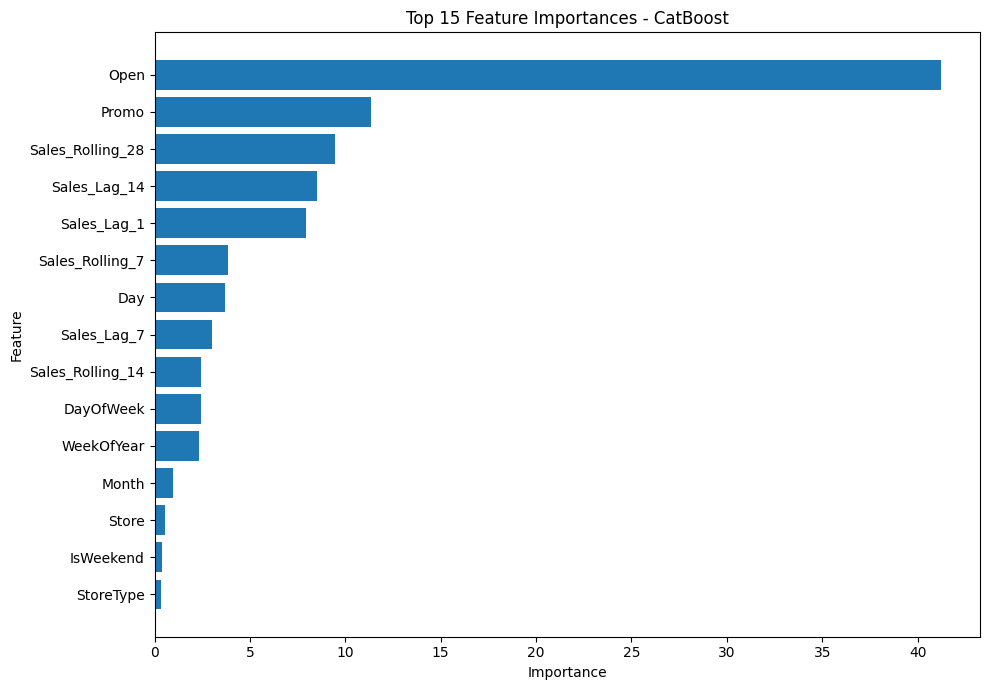

In [ ]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - CatBoost")
plt.tight_layout()
plt.show()

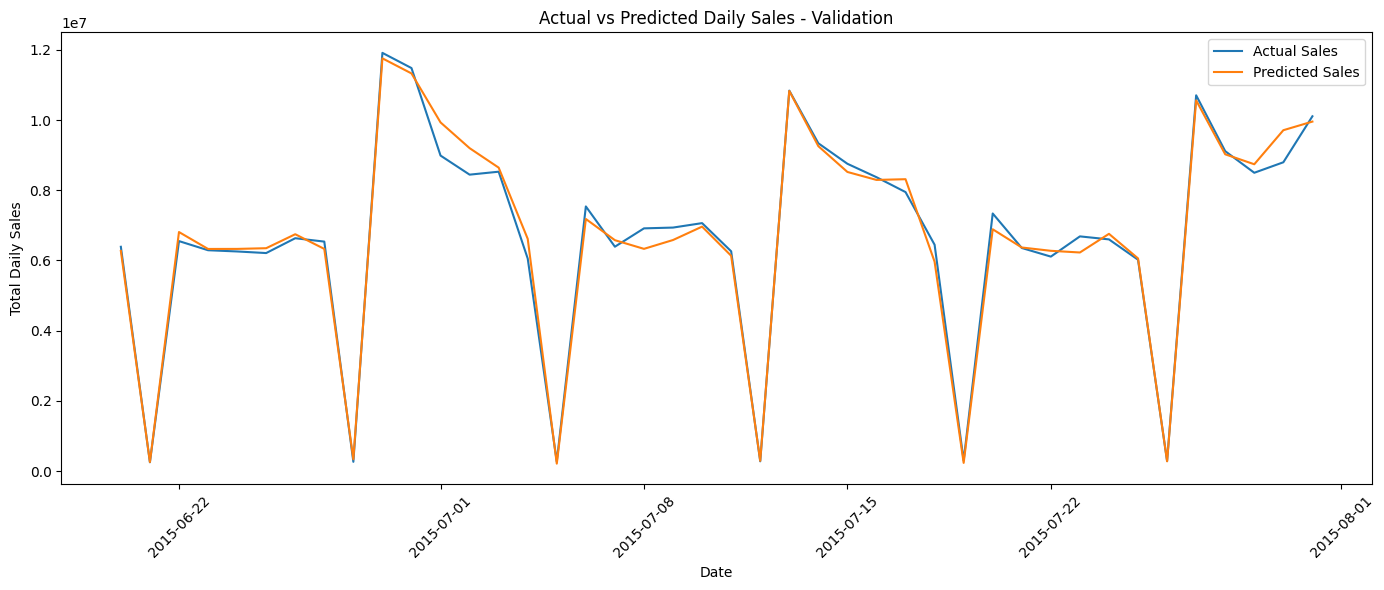

In [ ]:
plt.figure(figsize=(14, 6))

sample = validation_data.copy()
sample["PredictedSales"] = y_pred_v2

sample = sample.sort_values("Date")

daily_actual = sample.groupby("Date")["Sales"].sum()
daily_predicted = sample.groupby("Date")["PredictedSales"].sum()

plt.plot(daily_actual.index, daily_actual.values, label="Actual Sales")
plt.plot(daily_predicted.index, daily_predicted.values, label="Predicted Sales")

plt.xlabel("Date")
plt.ylabel("Total Daily Sales")
plt.title("Actual vs Predicted Daily Sales - Validation")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()